# Taller guiado · Primeros pasos con cuadernos y pandas
**Ciencia de Datos · Ingeniería Industrial · CORHUILA 2026‑B · Semana 8**

**Julian Andres Solano Ledesma y Juan David Caviedes Cortes**

Ya vimos la teoría: el proceso de la ciencia de datos, los tipos de datos y el ETL. Hoy lo **tocamos con las manos** por primera vez. Al terminar sabrás:

1. Qué es un cuaderno (`.ipynb`) y cómo se ejecuta.
2. Qué es una **librería** y para qué sirven **pandas** y **matplotlib**.
3. **Cargar** un archivo de datos y **explorarlo**.
4. **Graficar** los datos tal cual vienen… y descubrir sus problemas.
5. Hacer una **limpieza mínima** y volver a graficar para comparar.

> Todo el código ya está escrito y funciona. Tu trabajo: **ejecutar cada celda en orden, leer el resultado y responder las preguntas 🧠**.

## Parte 0 · ¿Qué es un cuaderno?
Un **cuaderno** (archivo `.ipynb`, *Jupyter Notebook*) mezcla dos tipos de **celdas**:

| Celda | Qué contiene | Cómo se ve |
|---|---|---|
| **Texto** (Markdown) | Explicaciones, títulos, tablas | Como esta que estás leyendo |
| **Código** (Python) | Instrucciones que la computadora ejecuta | Con fondo gris y un botón ▶ a la izquierda |

**Para ejecutar una celda de código:** haz clic en ella y presiona **`Shift + Enter`** (o el botón ▶). El resultado aparece justo debajo, y el cursor salta a la siguiente celda.

- El número entre corchetes `[1]`, `[2]`… indica **en qué orden** se ejecutaron las celdas.
- Las celdas se ejecutan **en orden, de arriba hacia abajo**: una celda puede usar lo que creó otra anterior.
- Si algo falla, usa **Ejecutar todo** (*Run All*) para correr el cuaderno completo desde el inicio.

Ejecuta la siguiente celda. Es tu primer programa:

In [1]:
print("¡Hola, Ciencia de Datos!")  # print() muestra este texto en la pantalla de salida


¡Hola, Ciencia de Datos!


`print(...)` **muestra** en pantalla lo que va entre paréntesis. El texto va entre comillas.

## Parte 1 · Python en cinco celdas
No necesitas ser programador para analizar datos, pero sí entender estas cinco ideas.

**1. Variables:** una variable es un nombre que guarda un valor. Se crea con `=`.

In [2]:
unidades = 1200        # variable que guarda un numero entero: total de unidades producidas
defectuosas = 30       # variable que guarda cuantas de esas unidades salieron defectuosas
maquina = "M-03"       # variable de texto (string): el codigo de la maquina, siempre entre comillas
print(maquina, "produjo", unidades, "unidades")  # imprime las tres variables separadas por espacios


M-03 produjo 1200 unidades


**2. Operaciones:** Python calcula como una calculadora. Aquí, el porcentaje de defectos.

In [3]:
tasa = defectuosas / unidades * 100                 # calcula el porcentaje: (defectuosas / total) * 100
print("Porcentaje de defectos:", tasa)              # muestra el resultado con todos sus decimales
print("Redondeado a 2 decimales:", round(tasa, 2))  # round(valor, 2) deja solo 2 decimales, mas facil de leer


Porcentaje de defectos: 2.5
Redondeado a 2 decimales: 2.5


**3. Listas:** varias cosas guardadas en orden, entre corchetes `[ ]`.

In [4]:
maquinas = ["M-01", "M-02", "M-03"]           # una lista: varios valores de texto guardados en orden, entre [ ]
print(maquinas)                                # imprime la lista completa, con sus corchetes y comas
print("Cantidad de maquinas:", len(maquinas))  # len() cuenta cuantos elementos tiene la lista


['M-01', 'M-02', 'M-03']
Cantidad de maquinas: 3


**4. Comentarios:** todo lo que va después de `#` es una nota para personas; Python lo ignora. En este taller los usamos para explicar cada línea.

In [5]:
# Esta linea es solo un comentario y no hace nada: Python la ignora por completo.
print("Los comentarios no se imprimen")  # esto que sigue al # tampoco se imprime, es solo una nota


Los comentarios no se imprimen


**5. Funciones y métodos:** una **función** es una acción con nombre que recibe datos entre paréntesis, como `print()`, `len()` o `round()`. Un **método** es una función que *pertenece* a un valor y se escribe con punto: `texto.upper()`.

In [6]:
codigo = " m-03 "                                        # texto con espacios de sobra al inicio y al final, a proposito
print("Original:   [" + codigo + "]")                   # muestra el texto tal cual, con sus espacios visibles entre corchetes
print("strip():    [" + codigo.strip() + "]")           # .strip() quita los espacios del inicio y del final del texto
print("upper():    [" + codigo.strip().upper() + "]")   # .upper() toma ese resultado y lo convierte a MAYUSCULAS


Original:   [ m-03 ]
strip():    [m-03]
upper():    [M-03]


🧠 **Responde:** ¿qué hizo `.strip()` y qué hizo `.upper()`? (Guárdalo en la memoria: los usaremos para limpiar datos.)

**Tu respuesta:** `.strip()` quitó los espacios en blanco que sobraban al inicio y al final del texto `" m-03 "`, dejando `"m-03"`. Después, `.upper()` tomó ese resultado (ya sin espacios) y convirtió todas sus letras a mayúsculas, dejando `"M-03"`. 


## Parte 2 · ¿Qué es una librería?
Una **librería** es código que otras personas ya escribieron y probaron, listo para usar. En vez de programar desde cero cómo leer un Excel o dibujar un gráfico, **importamos** una librería que ya lo sabe hacer.

| Librería | Para qué sirve | Cómo la llamamos |
|---|---|---|
| **pandas** | Trabajar con **tablas** de datos: cargar, filtrar, agrupar, limpiar. Es el "Excel de Python". | `pd` |
| **matplotlib** | Dibujar **gráficos** (líneas, barras, histogramas). pandas la usa por dentro. | `plt` |
| **numpy** | Cálculos numéricos rápidos. pandas está construida sobre ella. | `np` (hoy no la usamos directo) |

La siguiente celda comprueba que las librerías estén instaladas (en Colab ya vienen; en VS Code las instala solo si faltan) y luego las **importa**:

In [7]:
import importlib.util, subprocess, sys   # librerias del propio Python para revisar e instalar paquetes

faltan = [lib for lib in ["pandas", "matplotlib"] if importlib.util.find_spec(lib) is None]  # revisa cuales de las dos librerias NO estan instaladas
if faltan:                                   # si la lista "faltan" tiene al menos un elemento...
    print("Instalando:", faltan)             # avisa en pantalla cuales librerias va a instalar
    subprocess.check_call([sys.executable, "-m", "pip", "install", "-q", *faltan])  # las instala en silencio usando pip

import pandas as pd                 # trae la libreria pandas y le pone el apodo corto "pd"
import matplotlib.pyplot as plt     # trae el modulo de graficos de matplotlib con el apodo "plt"

print("pandas version", pd.__version__)   # muestra que version de pandas quedo instalada
print("¡Librerias listas!")               # confirma que la celda termino sin errores


pandas version 3.0.6
¡Librerias listas!


> `import pandas as pd` significa: *"trae la librería pandas y de ahora en adelante la llamaré `pd`"*. Por eso verás `pd.read_csv(...)`: es la función `read_csv` que vive dentro de pandas.

## Parte 3 · Cargar los datos
Trabajaremos con el registro de producción de una planta de empaques durante la **primera quincena de septiembre**: 3 máquinas, una fila por máquina y por día. Los datos son **ficticios**.

Un archivo **CSV** (*valores separados por comas*) es texto plano: la primera línea trae los nombres de las columnas y cada línea siguiente es una fila. Así se ve por dentro. La celda lo **guarda** como archivo en tu carpeta de trabajo:

In [8]:
from pathlib import Path   # Path ayuda a crear y guardar archivos dentro de la carpeta de trabajo

# contenido_csv es un texto largo (multilinea) con los datos crudos de la planta,
# escrito tal como llegaria un archivo .csv real: la primera linea trae los
# nombres de columna y cada linea siguiente es una fila. Trae, a proposito, los
# errores tipicos de un registro real: nombres de maquina escritos de varias
# formas, dos temperaturas vacias, un "M-01" con un cero de mas (11600) y dos
# filas repetidas.
contenido_csv = """fecha,maquina,unidades_producidas,unidades_defectuosas,temperatura_c
2026-09-01,M-01,1014,19,33.2
2026-09-01,M-02,1105,17,32.3
2026-09-01,M-03,893,56,37.4
2026-09-02,M-01,962,17,31.1
2026-09-02,m-02,973,6,31.4
2026-09-02,M-03,961,48,36.2
2026-09-03,M-01,1094,31,33.8
2026-09-03,M-02,1056,16,33.1
2026-09-03,M-03,834,51,39.4
2026-09-04,M-01,870,16,
2026-09-04,M-02,1014,12,31.0
2026-09-04,M-03,1072,59,36.3
2026-09-05,M-01,954,11,32.4
2026-09-05,M-02,1030,14,29.9
2026-09-05, M-03,1075,62,39.2
2026-09-06,M-01,1042,26,32.8
2026-09-06,M-02,1053,12,32.6
2026-09-06,M-03,918,52,36.7
2026-09-07,M-01,11600,31,33.0
2026-09-07,M-02,954,8,31.2
2026-09-07,M-03,1052,78,36.2
2026-09-08,M01,921,9,34.2
2026-09-08,M-02,1014,16,33.0
2026-09-08,M-03,1103,45,38.8
2026-09-09,M-01,1010,13,34.4
2026-09-09,M-02,973,25,30.4
2026-09-09,M-02,973,25,30.4
2026-09-09,M-03,931,53,37.7
2026-09-10,M-01,975,11,33.9
2026-09-10,M-02,1125,-4,31.6
2026-09-10,M-03,1099,63,38.3
2026-09-11,M-01,985,17,32.1
2026-09-11,M-02,1015,8,31.7
2026-09-11,m-03,788,44,36.2
2026-09-12,M-01,1050,16,32.7
2026-09-12,M-02,1016,7,31.4
2026-09-12,M-03,933,56,37.1
2026-09-13,M-01,903,24,31.8
2026-09-13,M-02,927,0,
2026-09-13,M-03,827,51,36.1
2026-09-14,M-01,1083,33,32.3
2026-09-14,M-01,1083,33,32.3
2026-09-14,M-02,935,18,30.3
2026-09-14,M-03,934,55,36.0
2026-09-15,M-01,1117,28,35.3
2026-09-15,M-02,1009,22,31.1
2026-09-15,M-03,1098,70,35.3"""

Path("produccion_septiembre.csv").write_text(contenido_csv, encoding="utf-8")  # crea (o sobreescribe) el archivo .csv en esta carpeta y le escribe el contenido de arriba
print("Archivo guardado. Primeras 4 lineas:")                                  # avisa que ya se guardo
print("\n".join(contenido_csv.splitlines()[:4]))                               # separa el texto en lineas y muestra solo las primeras 4, unidas otra vez con salto de linea


Archivo guardado. Primeras 4 lineas:
fecha,maquina,unidades_producidas,unidades_defectuosas,temperatura_c
2026-09-01,M-01,1014,19,33.2
2026-09-01,M-02,1105,17,32.3
2026-09-01,M-03,893,56,37.4


Ahora lo **cargamos** con pandas. `pd.read_csv()` lee el archivo y lo convierte en un **DataFrame**: una tabla con filas y columnas, como una hoja de Excel.

> En tus proyectos usarás la misma función con tu propio archivo: `pd.read_csv("mi_archivo.csv")`. Para Excel existe `pd.read_excel("archivo.xlsx")`. En Colab puedes subir archivos con el ícono de carpeta 📁 de la izquierda.

In [9]:
df = pd.read_csv("produccion_septiembre.csv")   # lee el archivo .csv y lo convierte en una tabla (DataFrame) llamada df
df.head()                                        # muestra las primeras 5 filas de la tabla, para verla de un vistazo


,fecha,maquina,unidades_producidas,unidades_defectuosas,temperatura_c
0,2026-09-01,M-01,1014,19,33.2
1,2026-09-01,M-02,1105,17,32.3
2,2026-09-01,M-03,893,56,37.4
3,2026-09-02,M-01,962,17,31.1
4,2026-09-02,m-02,973,6,31.4


Fíjate en la tabla: a la izquierda hay un número (0, 1, 2…) que pandas agrega solo; se llama **índice**. Las columnas tienen los nombres de la primera línea del CSV.

## Parte 4 · Explorar: conocer los datos antes de usarlos
Antes de analizar, **mira** los datos. Estas son las herramientas básicas de pandas:

In [10]:
print("Filas y columnas:", df.shape)       # df.shape entrega una pareja (numero de filas, numero de columnas)
print("Columnas:", list(df.columns))       # df.columns trae los nombres de columna; list() los muestra como una lista


Filas y columnas: (47, 5)
Columnas: ['fecha', 'maquina', 'unidades_producidas', 'unidades_defectuosas', 'temperatura_c']


In [11]:
df.tail(3)          # muestra las 3 ultimas filas de la tabla, para revisar el final del archivo


,fecha,maquina,unidades_producidas,unidades_defectuosas,temperatura_c
44,2026-09-15,M-01,1117,28,35.3
45,2026-09-15,M-02,1009,22,31.1
46,2026-09-15,M-03,1098,70,35.3


In [12]:
df.info()           # resume cada columna: su tipo de dato (Dtype) y cuantos valores NO vacios (Non-Null Count) tiene


<class 'pandas.DataFrame'>
RangeIndex: 47 entries, 0 to 46
Data columns (total 5 columns):
 #   Column                Non-Null Count  Dtype  
---  ------                --------------  -----  
 0   fecha                 47 non-null     str    
 1   maquina               47 non-null     str    
 2   unidades_producidas   47 non-null     int64  
 3   unidades_defectuosas  47 non-null     int64  
 4   temperatura_c         45 non-null     float64
dtypes: float64(1), int64(2), str(2)
memory usage: 2.0 KB


Lee la salida de `info()`:
- **Non-Null Count**: cuántos valores tiene cada columna. Si una columna tiene menos que el total de filas, **le faltan datos**.
- **Dtype** (tipo): `int64` = entero, `float64` = decimal, `object`/`str` = texto.

In [13]:
df.describe().round(1)     # calcula estadisticas (conteo, promedio, desviacion, minimo, cuartiles, maximo) de las columnas numericas y redondea a 1 decimal


,unidades_producidas,unidades_defectuosas,temperatura_c
count,47.0,47.0,45.0
mean,1220.3,29.4,33.9
std,1549.1,20.7,2.7
min,788.0,-4.0,29.9
25%,934.5,13.5,31.7
50%,1010.0,24.0,33.0
75%,1064.0,49.5,36.2
max,11600.0,78.0,39.4


🧠 **Responde:** mira la fila **max** de `unidades_producidas`. Si una máquina produce cerca de 1.000 unidades al día, ¿qué te dice ese máximo?

**Tu respuesta:** La fila `max` marca **11.600** unidades, casi **10 veces más** que lo normal, las demás filas rondan 800–1.100. Ninguna máquina de esta planta produce esa cantidad en un solo día, así que no es un récord de producción sino un **error de digitación**: muy probablemente se escribió un cero de más al capturar el dato. Ese valor hay que tratarlo en la limpieza  porque, si se deja así, infla el promedio y arruina cualquier gráfico o cálculo que use esa columna.


### Seleccionar una columna y filtrar filas

In [14]:
df["maquina"].head()        # selecciona solo la columna "maquina" (nombre entre corchetes y comillas) y muestra sus primeras filas


0    M-01
1    M-02
2    M-03
3    M-01
4    m-02
Name: maquina, dtype: str

In [15]:
df["maquina"].value_counts()    # cuenta cuantas filas hay para cada valor distinto que aparece en la columna "maquina"


maquina
M-01     15
M-02     15
M-03     13
m-02      1
 M-03     1
M01       1
m-03      1
Name: count, dtype: int64

🧠 **Responde:** deberían ser **3 máquinas con 15 días cada una**. ¿Qué ves en `value_counts()`? ¿Cuántos "nombres" distintos aparecen?

*Tu respuesta:* En vez de 3 nombres aparecen **7 "nombres" distintos**: `M-01` (15), `M-02` (15), `M-03` (13), `m-02` (1), ` M-03` (1, con espacio al inicio), `M01` (1) y `m-03` (1). No son máquinas nuevas: son la **misma máquina escrita de formas distintas** (mayúsculas/minúsculas, con o sin guión, con espacios de sobra). Para una persona es obvio que "m-03" y "M-03" son lo mismo, pero para pandas son dos textos diferentes hasta que se homologan.


In [16]:
df[df["unidades_producidas"] > 1100]   # "df['unidades_producidas'] > 1100" genera un True/False por fila; "df[...]" se queda solo con las filas donde salio True


,fecha,maquina,unidades_producidas,unidades_defectuosas,temperatura_c
1,2026-09-01,M-02,1105,17,32.3
18,2026-09-07,M-01,11600,31,33.0
23,2026-09-08,M-03,1103,45,38.8
29,2026-09-10,M-02,1125,-4,31.6
44,2026-09-15,M-01,1117,28,35.3


## Parte 5 · Graficar los datos TAL CUAL vienen
Un gráfico muestra en un segundo lo que en una tabla no se ve. pandas grafica con **`.plot()`** y usa matplotlib por dentro. Graficamos **sin limpiar nada**: queremos ver los datos como llegaron.

### 5.1 Gráfico de líneas: unidades producidas, fila por fila

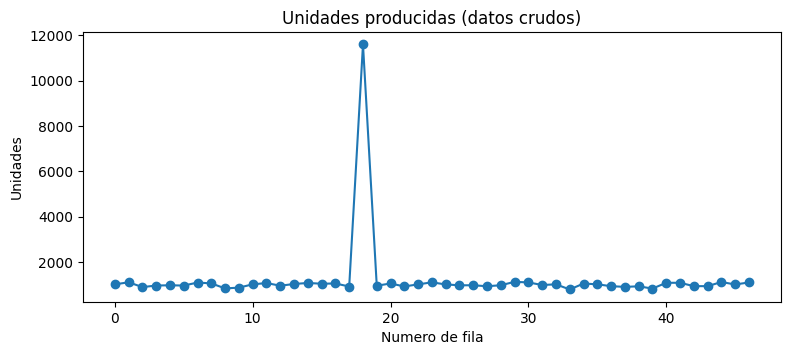

In [17]:
df["unidades_producidas"].plot(figsize=(9, 3.5), marker="o")  # dibuja un grafico de lineas con esa columna; figsize define el tamaño y marker="o" marca cada dato con un circulo
plt.title("Unidades producidas (datos crudos)")   # escribe el titulo del grafico
plt.xlabel("Numero de fila")                       # etiqueta el eje horizontal
plt.ylabel("Unidades")                             # etiqueta el eje vertical
plt.show()                                         # muestra el grafico terminado en pantalla


### 5.2 Gráfico de barras: filas por máquina

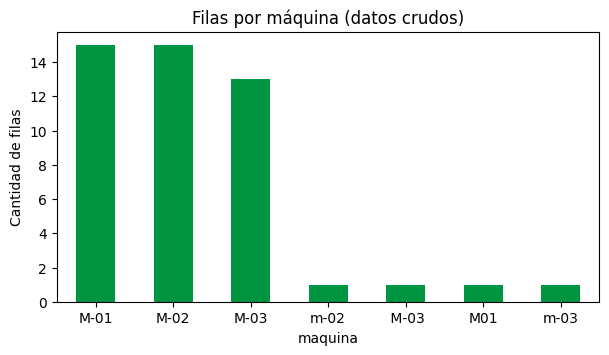

In [18]:
df["maquina"].value_counts().plot(kind="bar", figsize=(7, 3.5), color="#009540")  # cuenta filas por maquina y las dibuja como barras de color verde
plt.title("Filas por máquina (datos crudos)")   # escribe el titulo del grafico
plt.ylabel("Cantidad de filas")                  # etiqueta el eje vertical
plt.xticks(rotation=0)                           # deja las etiquetas del eje horizontal derechas, sin rotarlas
plt.show()                                       # muestra el grafico terminado en pantalla


> 👀 ¿Ves **M-03 dos veces**? No es un error del gráfico: una de ellas es `" M-03"`, con un **espacio invisible** al inicio. Para la computadora son textos distintos.

### 5.3 Histograma: ¿cómo se distribuye la temperatura?

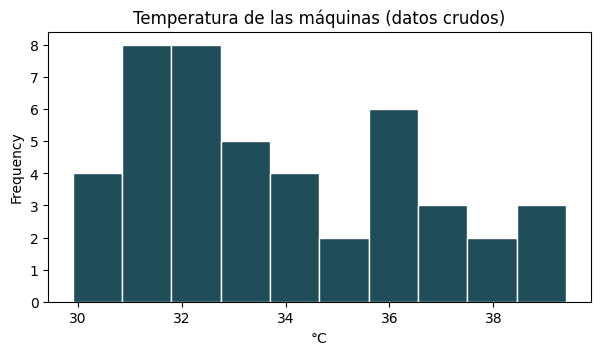

In [19]:
df["temperatura_c"].plot(kind="hist", bins=10, figsize=(7, 3.5), color="#1F4E5A", edgecolor="white")  # histograma: reparte las temperaturas en 10 rangos (bins) y cuenta cuantos datos caen en cada uno
plt.title("Temperatura de las máquinas (datos crudos)")   # escribe el titulo del grafico
plt.xlabel("°C")                                          # etiqueta el eje horizontal
plt.show()                                                # muestra el grafico terminado en pantalla


🧠 **Responde:** los gráficos acaban de delatar los problemas de calidad. Escribe **qué problema** revela cada uno:
1. El gráfico de líneas: muestra un **pico enorme** en una de las filas la de M-01 con 11.600 unidades el 7 de septiembre, muy por encima de las demás. Es la señal visual del **error de digitación** que ya habíamos sospechado con `describe()`.
2. El gráfico de barras: en vez de solo 3 barras, una por máquina, aparecen **7 barras**, porque el mismo código de máquina está escrito de varias formas (mayúsculas, minúsculas, con espacios, con o sin guión). Revela el problema de **nombres inconsistentes**.
3. `info()`, en la columna `temperatura_c`: su conteo de valores "Non-Null" es **menor** que el número total de filas (45 de 47), es decir, **hay datos faltantes** (vacíos) en esa columna.

*Tu respuesta:* Los tres problemas son: (1) un valor atípico/imposible por error de digitación, (2) nombres de máquina escritos de varias formas y (3) valores de temperatura vacíos. Los tres se ven en segundos en el gráfico, mientras que en la tabla cruda (`head()`, `tail()`) habría sido fácil pasarlos por alto.

> Esta es la "V" de **veracidad** que vimos en la semana 2: si analizamos estos datos sin limpiarlos, las conclusiones salen mal ("basura entra, basura sale").


## Parte 6 · Limpieza mínima
Vamos a corregir **cuatro** problemas, uno por celda. Trabajamos sobre una **copia** para no dañar los datos originales y poder comparar el antes y el después.

In [20]:
limpio = df.copy()                        # crea una copia independiente de df; los cambios en "limpio" no afectan a los datos originales
print("Filas al empezar:", len(limpio))   # len() cuenta cuantas filas tiene la copia antes de limpiar nada


Filas al empezar: 47


### 6.1 Homologar los códigos de máquina
`" M-03"`, `"m-03"` y `"M03"` son la misma máquina escrita de tres formas. Usamos los métodos de texto de la Parte 1, aplicados a **toda la columna** con `.str`:

In [21]:
limpio["maquina"] = (limpio["maquina"]
                     .str.strip()                                   # quita espacios de sobra al inicio y al final de cada texto de la columna
                     .str.upper()                                   # convierte cada texto a MAYUSCULAS
                     .str.replace("M0", "M-0", regex=False))        # reemplaza "M0" por "M-0" para que "M01" quede escrito como "M-01"
limpio["maquina"].value_counts()    # vuelve a contar los valores para comprobar que ya solo quedan 3 nombres de maquina


maquina
M-01    16
M-02    16
M-03    15
Name: count, dtype: int64

### 6.2 Quitar filas repetidas

In [22]:
print("Filas repetidas:", limpio.duplicated().sum())   # duplicated() marca True en las filas que son copia exacta de una fila anterior; sum() las cuenta
limpio = limpio.drop_duplicates()                       # elimina esas filas repetidas y deja solo una copia de cada una
print("Filas ahora:", len(limpio))                      # cuenta cuantas filas quedan despues de quitar las repetidas


Filas repetidas: 2
Filas ahora: 45


### 6.3 Valores vacíos (nulos)
`isna()` marca las celdas vacías y `.sum()` las cuenta por columna. Para la temperatura tenemos dos opciones: **eliminar** la fila o **rellenar** el vacío. Aquí rellenamos con la **mediana** de la temperatura de **esa misma máquina**, porque la producción de ese día sí es válida y no queremos perderla.

In [23]:
print("Vacíos por columna ANTES:\n", limpio.isna().sum(), "\n")   # isna() marca True en las celdas vacias; sum() las cuenta por columna, antes de corregir nada

mediana_por_maquina = limpio.groupby("maquina")["temperatura_c"].transform("median")   # calcula la mediana de temperatura de cada maquina y la repite en todas sus filas
limpio["temperatura_c"] = limpio["temperatura_c"].fillna(mediana_por_maquina)          # fillna() reemplaza unicamente las celdas vacias de temperatura, usando esa mediana

print("Vacíos por columna DESPUÉS:\n", limpio.isna().sum())   # vuelve a contar los vacios para comprobar que ya quedaron en 0


Vacíos por columna ANTES:
 fecha                   0
maquina                 0
unidades_producidas     0
unidades_defectuosas    0
temperatura_c           2
dtype: int64 

Vacíos por columna DESPUÉS:
 fecha                   0
maquina                 0
unidades_producidas     0
unidades_defectuosas    0
temperatura_c           0
dtype: int64


### 6.4 Un valor imposible
Una máquina produce alrededor de 1.000 unidades al día. El valor de **más de 10.000** es un error de digitación (un cero de más). Como no sabemos con certeza el valor real, **retiramos esa fila** y lo dejamos anotado.

In [24]:
print("Fila sospechosa:")                                          # avisa lo que se va a mostrar a continuacion
print(limpio[limpio["unidades_producidas"] > 5000])                # filtra y muestra la fila con un valor de produccion imposible (mas de 5000 unidades en un dia)

limpio = limpio[limpio["unidades_producidas"] <= 5000]              # se queda solo con las filas "normales" (<= 5000) y descarta la fila con el error de digitacion
print("\nFilas al terminar la limpieza:", len(limpio))              # cuenta cuantas filas quedan despues de este ultimo paso de limpieza


Fila sospechosa:
         fecha maquina  unidades_producidas  unidades_defectuosas  \
18  2026-09-07    M-01                11600                    31   

    temperatura_c  
18           33.0  

Filas al terminar la limpieza: 44


### 6.5 Fechas como fechas
La columna `fecha` se cargó como **texto**. La convertimos a tipo fecha para que los gráficos la ordenen como calendario.

In [25]:
limpio["fecha"] = pd.to_datetime(limpio["fecha"])   # convierte la columna "fecha", que estaba guardada como texto, al tipo fecha real de pandas
limpio.dtypes    # muestra el tipo de dato de cada columna para confirmar que "fecha" ya cambio


fecha                   datetime64[us]
maquina                            str
unidades_producidas              int64
unidades_defectuosas             int64
temperatura_c                  float64
dtype: object

**Resumen del antes y el después:**

| Problema | Antes | Después |
|---|---|---|
| Filas | 47 | 44 |
| Nombres de máquina distintos | 7 | 3 |
| Filas repetidas | 2 | 0 |
| Temperaturas vacías | 2 | 0 |
| Valores imposibles | 1 | 0 |

## Parte 7 · Graficar de nuevo y comparar
Ponemos lado a lado el **antes** y el **después**. `plt.subplots(1, 2)` crea una figura con dos gráficos en una fila.

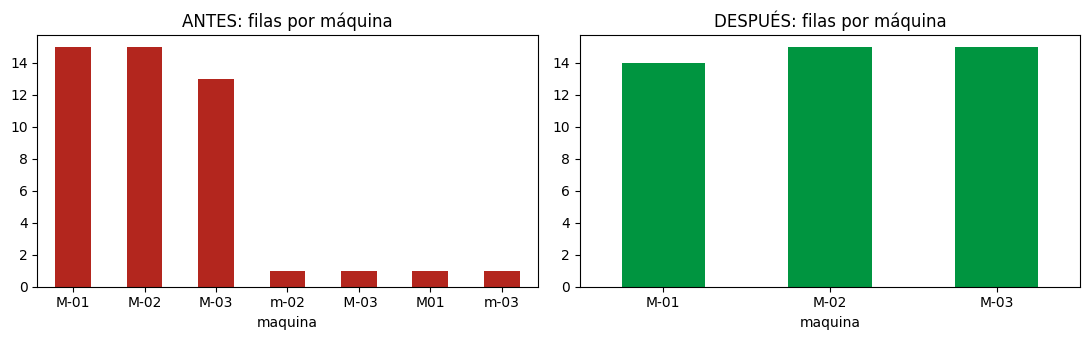

In [26]:
fig, (izq, der) = plt.subplots(1, 2, figsize=(11, 3.5))   # crea una figura con 2 graficos lado a lado (1 fila, 2 columnas) y guarda cada eje en "izq" y "der"

df["maquina"].value_counts().plot(kind="bar", ax=izq, color="#B3261E")   # dibuja en el grafico izquierdo las barras de los datos ANTES de limpiar, en rojo
izq.set_title("ANTES: filas por máquina")     # titulo del grafico izquierdo
izq.tick_params(axis="x", rotation=0)         # deja las etiquetas del eje horizontal sin rotar

limpio["maquina"].value_counts().sort_index().plot(kind="bar", ax=der, color="#009540")   # dibuja en el grafico derecho las barras de los datos DESPUÉS de limpiar (ordenadas alfabeticamente), en verde
der.set_title("DESPUÉS: filas por máquina")   # titulo del grafico derecho
der.tick_params(axis="x", rotation=0)         # deja las etiquetas del eje horizontal sin rotar

plt.tight_layout()   # ajusta los espacios entre los graficos para que no se encimen
plt.show()            # muestra la figura completa con los dos graficos


### Ahora sí, un gráfico que responde una pregunta: ¿cómo produjo cada máquina día a día?

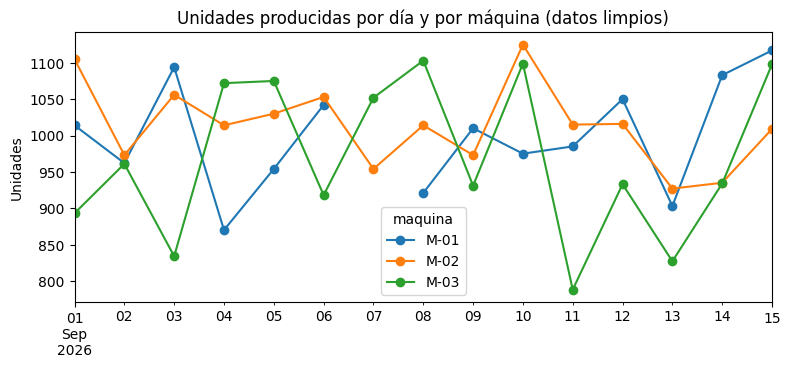

In [27]:
por_dia = limpio.pivot_table(index="fecha", columns="maquina", values="unidades_producidas")   # reorganiza la tabla: una fila por fecha, una columna por maquina, con las unidades producidas como valor
por_dia.plot(figsize=(9, 3.5), marker="o")   # dibuja una linea por maquina (una linea por cada columna de por_dia)
plt.title("Unidades producidas por día y por máquina (datos limpios)")   # titulo del grafico
plt.ylabel("Unidades")   # etiqueta del eje vertical
plt.xlabel("")            # deja vacia la etiqueta del eje horizontal, porque ya se entiende que son fechas
plt.show()                # muestra el grafico terminado


> `pivot_table` **reorganiza** la tabla: pone las fechas en las filas y una columna por máquina. Así pandas dibuja una línea por máquina.

🧠 **Responde:** ¿por qué la línea de **M-01** se interrumpe el **7 de septiembre**? (Pista: Parte 6.4.) ¿Es mejor un hueco honesto que un dato inventado?

*Tu respuesta:* La línea de M-01 se corta ese día porque en la Parte 6.4 **eliminamos** la fila con el valor imposible de 11.600 unidades (el error de digitación); al no reemplazarla por ningún otro número, `pivot_table` simplemente no tiene un dato para graficar ahí y deja un **hueco**. Sí, es mejor un hueco honesto que un dato inventado: si hubiéramos "adivinado" un valor (por ejemplo, el promedio) estaríamos presentando como real algo que la máquina nunca reportó, y eso puede maquillar un problema real de producción o de captura de datos. El hueco le dice a quien lee el gráfico "aquí no tenemos un dato confiable", que es la verdad.


## Parte 8 · Tu primera respuesta con datos
¿Qué máquina tiene **más defectos**? Calculamos el porcentaje de unidades defectuosas y lo **agrupamos por máquina** con `groupby`.

In [28]:
limpio["pct_defectos"] = limpio["unidades_defectuosas"] / limpio["unidades_producidas"] * 100   # crea una columna nueva con el porcentaje de unidades defectuosas de cada fila

resumen = limpio.groupby("maquina")[["pct_defectos", "temperatura_c"]].mean().round(2)   # agrupa las filas por maquina y calcula el promedio de %defectos y temperatura, redondeado a 2 decimales
resumen   # muestra la tabla resumen final


,pct_defectos,temperatura_c
maquina,,
M-01,1.92,33.06
M-02,1.17,31.49
M-03,5.82,37.13


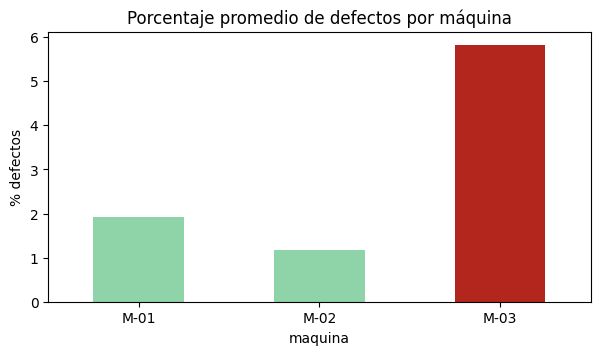

In [29]:
resumen["pct_defectos"].plot(kind="bar", figsize=(7, 3.5), color=["#8FD3A8", "#8FD3A8", "#B3261E"])   # grafica en barras el % de defectos de cada maquina; la lista de colores resalta a M-03 en rojo
plt.title("Porcentaje promedio de defectos por máquina")   # titulo del grafico
plt.ylabel("% defectos")   # etiqueta del eje vertical
plt.xticks(rotation=0)     # deja las etiquetas del eje horizontal sin rotar
plt.show()                 # muestra el grafico terminado


🧠 **Responde:**
1. ¿Qué máquina tiene más defectos? ¿Es también la de mayor temperatura promedio?
2. Recuerda la semana 1: ¿esto demuestra que la temperatura **causa** los defectos? ¿Qué más revisarías?
3. Si **no** hubieras limpiado los datos, ¿qué habría salido mal en esta tabla?

*Tu respuesta:*
1. **M-03** tiene el mayor porcentaje promedio de defectos, con **5.82 %**, muy por encima de M-01 (1.92 %) y M-02 (1.17 %). M-03 también es la máquina con la **mayor temperatura promedio** (37.13 °C, frente a 33.06 °C de M-01 y 31.49 °C de M-02), así que sí hay una máquina que combina ambos extremos.
2. No, esto **no demuestra causalidad**: que M-03 sea la más caliente y la más defectuosa al mismo tiempo es una **correlación**, no una prueba de que la temperatura *cause* los defectos. Recordando la semana 1, "correlación no es causalidad": podría haber otra explicación (M-03 es un modelo distinto o más antiguo, tiene otro operario, otro tipo de molde, mantenimiento vencido, etc.). Antes de intervenir la máquina revisaría, por ejemplo: el historial de mantenimiento de M-03, si la temperatura sube *antes* de que aparezcan los defectos (para ver si hay una relación en el tiempo), y si controlando por turno u operario la relación se mantiene.
3. Sin limpiar los datos: (a) el promedio de unidades y de % de defectos habría quedado **inflado o distorsionado** por la fila de 11.600 unidades y por la fila con -4 defectos; (b) el `groupby("maquina")` habría creado grupos de más (hasta 7 "máquinas" distintas en vez de 3) por los nombres sin homologar, repartiendo mal los datos de M-03 entre varias filas; (c) las dos filas repetidas habrían contado dos veces la producción de esos días, sesgando el promedio; y (d) la columna de temperatura con vacíos habría hecho que algunos cálculos (como el promedio) se calcularan con menos datos de los que realmente hay, sin que se note a simple vista.


## Parte 9 · Guardar el resultado
Guardamos los datos limpios en un nuevo CSV. Así el trabajo queda listo para el siguiente paso (por ejemplo, un tablero en Power BI).

In [30]:
limpio.to_csv("produccion_septiembre_limpio.csv", index=False)   # guarda la tabla ya limpia en un nuevo archivo .csv; index=False evita guardar la columna de indice
print("Guardado: produccion_septiembre_limpio.csv ·", len(limpio), "filas")   # confirma el nombre del archivo y cuantas filas quedaron guardadas


Guardado: produccion_septiembre_limpio.csv · 44 filas


## ✅ Resumen: lo que usaste hoy

| Quiero… | Código |
|---|---|
| Traer una librería | `import pandas as pd` |
| Cargar un CSV | `pd.read_csv("archivo.csv")` |
| Ver las primeras / últimas filas | `df.head()` · `df.tail()` |
| Tamaño y tipos | `df.shape` · `df.info()` |
| Estadísticas | `df.describe()` |
| Contar valores de una columna | `df["col"].value_counts()` |
| Filtrar filas | `df[df["col"] > 100]` |
| Graficar | `.plot()` · `.plot(kind="bar")` · `.plot(kind="hist")` |
| Limpiar texto | `.str.strip()` · `.str.upper()` · `.str.replace()` |
| Quitar repetidas | `df.drop_duplicates()` |
| Contar y rellenar vacíos | `df.isna().sum()` · `.fillna(valor)` |
| Agrupar y promediar | `df.groupby("col")["otra"].mean()` |
| Guardar | `df.to_csv("nuevo.csv", index=False)` |

**Entrega:** descarga este cuaderno (en Colab: *Archivo → Descargar → .ipynb*; en VS Code ya es un archivo) y súbelo a tu fork en `08-week/01-session/`.

**Próxima clase:** con estas mismas herramientas armaremos un **pipeline ETL completo**: tres fuentes (CSV, JSON y una API real), limpieza a fondo, una base de datos SQL y una decisión de mantenimiento.